# Day 1
### _The password to the safe is give by the number of times the dial points towards 0 in a series of rotations_

- The sequence is attached in `.\Artifacts\Day1.txt`

## Approach:

- Right rotations increase the count _i.e. positive addition_
- Left rotations decrease the count _i.e. negative addition_

1. Convert sequence to a dataframe from .txt
2. Regex / string parse each row to convert R / L to + / -
3. Create cumulative count, flag whenever running total = 0 or a +/- multiple of 100

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read data

sequence = pd.read_csv('/Users/Ben.Pharris/Documents/project-dev/Ad Hoc/Personal/AoC2025/Artifacts/Day1.txt', header=None, names = ['Turns'])
sequence.head()

,Turns
0,R19
1,R5
2,R29
3,R30
4,L24


In [3]:
# Parse out turns and values

def process_turns(df: pd.DataFrame):
    df['Direction'] = df['Turns'].str.replace(r'[^a-zA-Z]', '', regex=True)
    df['Value'] = df['Turns'].str.replace(r'[^0-9]', '', regex=True).astype(int)
    return df

In [4]:
# Parse Strings

sequence_processed = process_turns(sequence)
sequence_processed.head()

,Turns,Direction,Value
0,R19,R,19
1,R5,R,5
2,R29,R,29
3,R30,R,30
4,L24,L,24


In [5]:
# Convert turns to sign change

sequence_processed['Value'] = np.where(sequence_processed['Direction'] == 'R', sequence_processed['Value'] * 1 , sequence_processed['Value'] * -1)

    #Start at 50 - Alternatively, add 50 to the cumulative sum
    #sequence_processed.loc[0, 'Value'] += 50 

sequence_processed.head()

,Turns,Direction,Value
0,R19,R,19
1,R5,R,5
2,R29,R,29
3,R30,R,30
4,L24,L,-24


In [6]:
# Cumulative Sum of the Column
sequence_processed['CumulativeVal'] = sequence_processed['Value'].cumsum() + 50

In [7]:
# Modulus to Check for Multiple of 100 0 inclusive - 0 if it lands in the middle, integer otherwise

sequence_processed['Mod'] = sequence_processed['CumulativeVal'] % 100

sequence_processed['Mod'].head()

0    69
1    74
2     3
3    33
4     9
Name: Mod, dtype: int64

In [8]:
# Flag whenever the modulus of the cumulative sum = 0 (i.e. landed at 12:00)

sequence_processed['Flag'] = np.where(sequence_processed['Mod'] == 0, 1, 0)

In [9]:
# Final Answer
final_answer = sequence_processed['Flag'].sum()
print(f"Final Answer is {final_answer}")

Final Answer is 1078


### Pt. II

- After much head smashing, I tapped out - oh well

- Solution: If we're going right to left, 

In [10]:
# Scale down - crossing whole numbers means crossing 0 on the dial

sequence_processed['Scale'] = sequence_processed['CumulativeVal'] / 100

sequence_processed['Previous'] =  sequence_processed['Scale'].shift(1).fillna(sequence_processed['Scale'])


In [11]:
Crosses = np.where(sequence_processed['Scale'] > sequence_processed['Previous'], 
                    np.floor(sequence_processed['Scale']) -  np.floor(sequence_processed['Previous']),
                    np.ceil(sequence_processed['Previous']) - np.ceil(sequence_processed['Scale']))

answer = abs(Crosses).sum()

print(answer)

6412.0


### Other Guesses

- We just need to check if we cross 0 
    - This is a surprisingly hard thing to code

    - Translating this into our running total space:
        - We count a click when:
            - The sign changes (+ to -, - to +)
            - The running total = 0
            - The running total passes an integer multiple of 100 (+ or -)
        - We can write these mathematically:
            - $\frac{RunningTotal_n}{RunningTotal_(n-1)} =< 0 | abs($
            - You can't write out the last condition with mod
            - You also can't just check if it's divisible by 100 with no remainder
            - You have to use some operator that checks if 100's place changes
                - That means rounding up ...


    - This solution is probably the simplest way to make it work
    - If you're going down, you have to round up
    - If you're going up, you have to round down (nearest 100)

- I think trig makes this easier ... lets try 


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
import math

trig = pd.DataFrame()

x = np.linspace(0, 2*np.pi, 100)
y = np.cos(x)
z = np.sin(x)

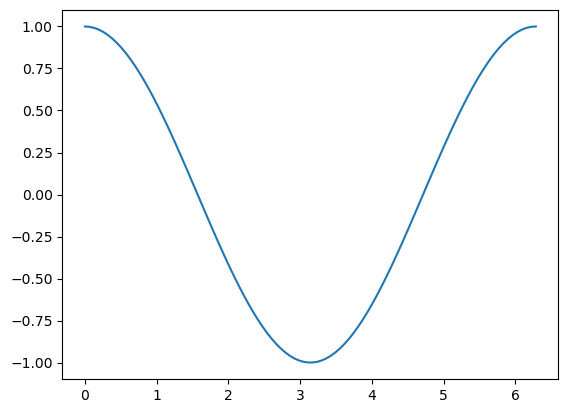

In [14]:
plot = plt.plot(x, y)

Value is currently actually an angle specification

- We can find the number of times it crosses 0 by converting the ticks to radians

- since 100 is the top of the lock we take $\frac{2\pi}{100} * Value$ to get radians - easy

- Then we do the same thing - get a cumulative angle, plot (for fun), then count the peaks


In [23]:
rads = sequence_processed['CumulativeVal'] * (2*np.pi / 100)


y = np.cos(rads)

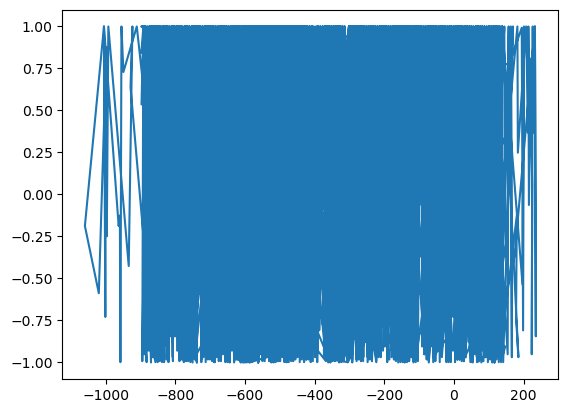

In [24]:
plot = plt.plot(rads,y)

In [25]:
peaks = (y > 0.9) 
total_landings = peaks.sum()

print(total_landings)

1524


### Considerations

This is a decent approximation but even accounting for floating point rounding, if we jump between values the cos of the value won't move smoothly between them

In [26]:
# To handle the discrete points, we expand the increments to continuous individual steps

jumps = sequence_processed['Value']

ticks = []

for jump in jumps:
    step = 1 if jump > 0 else -1
    ticks.extend([step] * int(abs(jump)))


interp = pd.DataFrame({'Step': ticks})

interp['Dial_Position'] = interp['Step'].cumsum() + 50

interp['Rads'] = interp['Dial_Position'] * (2*np.pi / 100)
interp['y'] = np.cos(interp['Rads'])

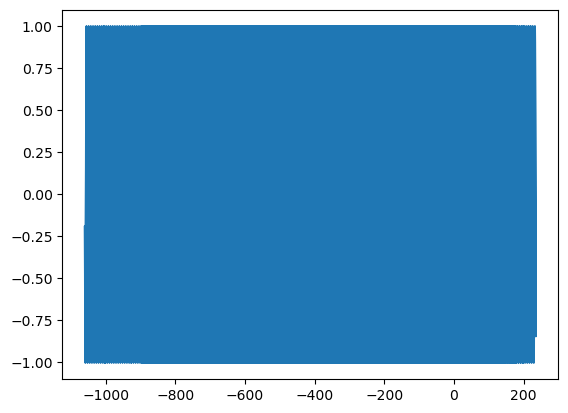

In [27]:
plt.plot(interp['Rads'], interp['y'])

In [30]:
from scipy.signal import find_peaks

# Find indices where y hits a peak (top of the lock)
top_peaks, _ = find_peaks(interp['y'], height=0.999)


# Count the number of times the interpolated y values are at or above 0.999
simple_peaks = (interp['y'] >= 0.999).sum()
print(f"Simple counting of peaks: {simple_peaks}")
print(f"Scipy find peaks - # of times landed on 0: {len(top_peaks)}")




Simple counting of peaks: 6412
Scipy find peaks - # of times landed on 0: 6412
